# Common Libraries

In [1]:
import os, sys, shutil, mediapy
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pylab as plt
from ipywidgets import interact

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# Custom Libraries

In [2]:
sys.path.append("/home/seojin/Seojin_commonTool/Module")

from biomechanics_util import get_mujoco_joints

In [3]:
def get_indices(model, joint_name):
    jnt_id = model.joint(joint_name).id
    qpos_idx = model.jnt_qposadr[jnt_id]
    dof_idx = model.jnt_dofadr[jnt_id]
    return qpos_idx, dof_idx

In [4]:
def get_qfrc(model, data, target_qpos):
    """
    Compute the generalized force needed to reach the target position in the next mujoco step.
    """
    data_copy = mujoco.MjData(model)
    data_copy.qpos = data.qpos.copy()
    data_copy.qvel = data.qvel.copy()
    data_copy.qacc = (((target_qpos - data.qpos) / model.opt.timestep) - data.qvel) / model.opt.timestep
    model.opt.disableflags += mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    mujoco.mj_inverse(model, data_copy)
    model.opt.disableflags -= mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    return data_copy.qfrc_inverse

# Params

In [5]:
model_path = "/mnt/sdb2/DeepProprioception/Projects/DP01_mri/Myosuite/myoarm/myoarm_mocap.xml"

# Initialize model

In [19]:
model = mujoco.MjModel.from_xml_path(model_path)
simulation_timestep = model.opt.timestep

# Model constants
joint_info_df = get_mujoco_joints(model_path)
joint_names = list(joint_info_df.columns.to_numpy())
independent_joint_names = joint_info_df.columns[joint_info_df.loc["independent"] == True].tolist()
independent_dof_indices = [get_indices(model, joint_name)[1] for joint_name in independent_joint_names]
n_joint = len(joint_names)

# Joint indexing
elevation_angle_q, elevation_angle_d = get_indices(model, "elv_angle")
shoulder_elevation_angle_q, shoulder_elevation_angle_d = get_indices(model, "shoulder_elv")
elbow_flexion_q, elbow_flexion_d = get_indices(model, "elbow_flexion")

# Initialize pose
mj_data = mujoco.MjData(model)
mujoco.mj_forward(model, mj_data)

# Renderer

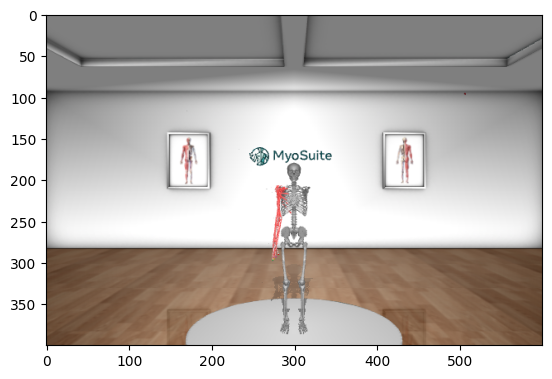

In [20]:
# Renderer
renderer = mujoco.Renderer(model, height=400, width=600)
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_WORLD

# Camera
camera = mujoco.MjvCamera()
camera.azimuth = 90
camera.elevation = 0
camera.distance = 4
camera.lookat = [0,0,1.5]

# Initial render
renderer.update_scene(mj_data, camera=camera, scene_option=scene_option)
plt.imshow(renderer.render())

# Simulate shoulder elevation

In [21]:
n_times = 100

# Initialize start pose
mj_data = mujoco.MjData(model)
mujoco.mj_forward(model, mj_data)

# Goal
final_goal_qpos = mj_data.qpos.copy()
final_goal_qpos[shoulder_elevation_angle_q] = 0 # 1.6

# Image
pixels = np.zeros((n_times, renderer.height, renderer.width, 3), dtype = np.uint8)

# Force
qforces = pd.DataFrame(np.zeros((n_times, n_joint)))
qforces.columns = joint_names

# Error
qerrors = pd.DataFrame(np.zeros((n_times, n_joint)))
qerrors.columns = joint_names

# Simulation
for time_i in tqdm(range(n_times)):
    # Current
    current_qpos = mj_data.qpos.copy()
    current_qvel = mj_data.qvel.copy()
    
    # Control
    error_q = np.zeros(n_joint)
    error_q[shoulder_elevation_angle_q] = final_goal_qpos[shoulder_elevation_angle_q] - current_qpos[shoulder_elevation_angle_q]
    qerrors.iloc[time_i] = error_q

    # mj inverse
    tau_all = get_qfrc(model, mj_data, final_goal_qpos)    
    qfrc_applied = np.zeros(len(tau_all))
    qfrc_applied[independent_dof_indices] = tau_all[independent_dof_indices]
    mj_data.qfrc_applied[:] = qfrc_applied
    qforces.iloc[time_i] = qfrc_applied

    # Forward dyanmics
    mujoco.mj_step(model, mj_data)

    # Rendering
    renderer.update_scene(mj_data, camera = camera, scene_option = scene_option)
    pixels[time_i] = renderer.render()

100%|██████████| 100/100 [00:00<00:00, 143.64it/s]


In [22]:
mediapy.show_video(pixels, fps = 1, loop=False)

This browser does not support the video tag.


# Simulate elevation angle

In [23]:
# Initialize start pose
mj_data = mujoco.MjData(model)
mujoco.mj_forward(model, mj_data)

# Goal
final_goal_qpos = mj_data.qpos.copy()
final_goal_qpos[elevation_angle_q] = 1.5708

# Image
pixels = np.zeros((n_times, renderer.height, renderer.width, 3), dtype = np.uint8)

# Force
qforces = pd.DataFrame(np.zeros((n_times, n_joint)))
qforces.columns = joint_names

# Error
qerrors = pd.DataFrame(np.zeros((n_times, n_joint)))
qerrors.columns = joint_names

# Simulation
for time_i in tqdm(range(n_times)):
    # Current
    current_qpos = mj_data.qpos.copy()
    current_qvel = mj_data.qvel.copy()
    
    # Control
    error_q = np.zeros(n_joint)
    error_q[elevation_angle_q] = final_goal_qpos[elevation_angle_q] - current_qpos[elevation_angle_q]
    qerrors.iloc[time_i] = error_q

    # Force
    tau_all = get_qfrc(model, mj_data, final_goal_qpos)    
    qfrc_applied[independent_dof_indices] = tau_all[independent_dof_indices]
    mj_data.qfrc_applied[:] = qfrc_applied
    qforces.iloc[time_i] = tau_all

    # Forward dyanmics
    mujoco.mj_step(model, mj_data)

    # Rendering
    renderer.update_scene(mj_data, camera = camera, scene_option = scene_option)
    pixels[time_i] = renderer.render()

100%|██████████| 100/100 [00:00<00:00, 132.77it/s]


In [24]:
mediapy.show_video(pixels, fps = 1, loop=False)

This browser does not support the video tag.
